In [4]:
# Section 1 — Dataset Introduction
# Why chosen:
# Contains socio-economic indicators (GDP, life expectancy, freedom, etc.)
# Good mix of numerical + categorical data
# Useful for correlation and global analysis
import pandas as pd
df = pd.read_csv('2019.csv')
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [5]:
# Section 2 — 7 First-Look Protocol
df.shape
# The dataset has 156 rows and 9 columns, which is sufficient for EDA. It provides enough observations across countries.

(156, 9)

In [7]:
df.dtypes
# Most columns are numeric (float), which is good for analysis. Country is an object (text). No obvious incorrect types.

,0
Overall rank,int64
Country or region,object
Score,float64
GDP per capita,float64
Social support,float64
Healthy life expectancy,float64
Freedom to make life choices,float64
Generosity,float64
Perceptions of corruption,float64


In [9]:
df.info()
# Shows missing values and memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


In [10]:
df.describe()
# Happiness score and GDP show variation. If mean ≠ median → skewness exists. Outliers may exist in GDP.

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [51]:
df.isnull().sum()
# Columns with high missing % need attention (drop/impute). Low missing values can be filled.

,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


In [12]:
df['Country or region'].value_counts()
# Each country appears once → no duplication in country entries.

,count
Country or region,
Finland,1
Denmark,1
Norway,1
Iceland,1
Netherlands,1
...,...
Rwanda,1
Tanzania,1
Afghanistan,1


In [13]:
df.duplicated().sum()
# If 0 → dataset is clean. If >0 → duplicates must be removed.

np.int64(0)

In [14]:
# Section 3 — 20+ Additional EDA Commands
df.head(10)
# Shows first 10 rows to understand structure and formatting.

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343
6,7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
9,10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


In [15]:
df.tail(5)
# Last rows confirm no corruption at dataset end.

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035
155,156,South Sudan,2.853,0.306,0.575,0.295,0.010,0.202,0.091


In [17]:
df.sample(5)
# Random rows give unbiased view of dataset.

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
42,43,Colombia,6.125,0.985,1.410,0.841,0.470,0.099,0.034
51,52,Thailand,6.008,1.050,1.409,0.828,0.557,0.359,0.028
111,112,Somalia,4.668,0.000,0.698,0.268,0.559,0.243,0.270
78,79,Turkey,5.373,1.183,1.360,0.808,0.195,0.083,0.106
13,14,Luxembourg,7.090,1.609,1.479,1.012,0.526,0.194,0.316


In [18]:
df.columns.tolist()
# Confirms column names and checks for hidden spaces.

['Overall rank',
 'Country or region',
 'Score',
 'GDP per capita',
 'Social support',
 'Healthy life expectancy',
 'Freedom to make life choices',
 'Generosity',
 'Perceptions of corruption']

In [19]:
df.nunique()
# Country has many unique values → identifier column.

,0
Overall rank,156
Country or region,156
Score,155
GDP per capita,146
Social support,145
Healthy life expectancy,119
Freedom to make life choices,130
Generosity,118
Perceptions of corruption,113


In [20]:
df['Country or region'].unique()
# Lists all countries.

array(['Finland', 'Denmark', 'Norway', 'Iceland', 'Netherlands',
       'Switzerland', 'Sweden', 'New Zealand', 'Canada', 'Austria',
       'Australia', 'Costa Rica', 'Israel', 'Luxembourg',
       'United Kingdom', 'Ireland', 'Germany', 'Belgium', 'United States',
       'Czech Republic', 'United Arab Emirates', 'Malta', 'Mexico',
       'France', 'Taiwan', 'Chile', 'Guatemala', 'Saudi Arabia', 'Qatar',
       'Spain', 'Panama', 'Brazil', 'Uruguay', 'Singapore', 'El Salvador',
       'Italy', 'Bahrain', 'Slovakia', 'Trinidad & Tobago', 'Poland',
       'Uzbekistan', 'Lithuania', 'Colombia', 'Slovenia', 'Nicaragua',
       'Kosovo', 'Argentina', 'Romania', 'Cyprus', 'Ecuador', 'Kuwait',
       'Thailand', 'Latvia', 'South Korea', 'Estonia', 'Jamaica',
       'Mauritius', 'Japan', 'Honduras', 'Kazakhstan', 'Bolivia',
       'Hungary', 'Paraguay', 'Northern Cyprus', 'Peru', 'Portugal',
       'Pakistan', 'Russia', 'Philippines', 'Serbia', 'Moldova', 'Libya',
       'Montenegro', 'Tajikis

In [21]:
df.corr(numeric_only=True)
# Shows which variables influence happiness score (GDP likely strong).

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Overall rank,1.000000,-0.989096,-0.801947,-0.767465,-0.787411,-0.546606,-0.047993,-0.351959
Score,-0.989096,1.000000,0.793883,0.777058,0.779883,0.566742,0.075824,0.385613
GDP per capita,-0.801947,0.793883,1.000000,0.754906,0.835462,0.379079,-0.079662,0.298920
Social support,-0.767465,0.777058,0.754906,1.000000,0.719009,0.447333,-0.048126,0.181899
Healthy life expectancy,-0.787411,0.779883,0.835462,0.719009,1.000000,0.390395,-0.029511,0.295283
Freedom to make life choices,-0.546606,0.566742,0.379079,0.447333,0.390395,1.000000,0.269742,0.438843
Generosity,-0.047993,0.075824,-0.079662,-0.048126,-0.029511,0.269742,1.000000,0.326538
Perceptions of corruption,-0.351959,0.385613,0.298920,0.181899,0.295283,0.438843,0.326538,1.000000


<Axes: >

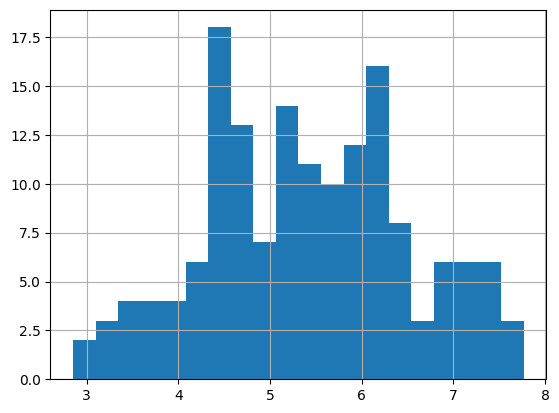

In [36]:
df['Score'].hist(bins=20)
# Shows distribution of happiness scores.

In [37]:
df.groupby('Overall rank').mean(numeric_only=True)
# Shows how happiness changes over rank.

,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Overall rank,,,,,,,
1,7.769,1.340,1.587,0.986,0.596,0.153,0.393
2,7.600,1.383,1.573,0.996,0.592,0.252,0.410
3,7.554,1.488,1.582,1.028,0.603,0.271,0.341
4,7.494,1.380,1.624,1.026,0.591,0.354,0.118
5,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...
152,3.334,0.359,0.711,0.614,0.555,0.217,0.411
153,3.231,0.476,0.885,0.499,0.417,0.276,0.147
154,3.203,0.350,0.517,0.361,0.000,0.158,0.025


In [38]:
df['Overall rank'].value_counts(normalize=True)
# Shows distribution of records per rank.

,proportion
Overall rank,
1,0.00641
2,0.00641
3,0.00641
4,0.00641
5,0.00641
...,...
152,0.00641
153,0.00641
154,0.00641


In [39]:
df.select_dtypes(include='object')
# Lists categorical columns.

,Country or region
0,Finland
1,Denmark
2,Norway
3,Iceland
4,Netherlands
...,...
151,Rwanda
152,Tanzania
153,Afghanistan
154,Central African Republic


In [41]:
df['Country or region'].str.contains('United').sum()
# Counts countries with "United".

np.int64(3)

In [42]:
df.sort_values('Score', ascending=False).head(5)
# Top happiest countries.

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [43]:
df[df['Score'] > 7]
# Highly happy countries.

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,6,Switzerland,7.480,1.452,1.526,1.052,0.572,0.263,0.343
6,7,Sweden,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,8,New Zealand,7.307,1.303,1.557,1.026,0.585,0.330,0.380
8,9,Canada,7.278,1.365,1.505,1.039,0.584,0.285,0.308
9,10,Austria,7.246,1.376,1.475,1.016,0.532,0.244,0.226


In [44]:
pd.pivot_table(df, values='Score', index='Overall rank', aggfunc='mean')
# Average happiness per rank.

,Score
Overall rank,
1,7.769
2,7.600
3,7.554
4,7.494
5,7.488
...,...
152,3.334
153,3.231
154,3.203


In [45]:
df.skew(numeric_only=True)
# Shows skewness in data distribution.

,0
Overall rank,0.000000
Score,0.011450
GDP per capita,-0.385232
Social support,-1.134728
Healthy life expectancy,-0.613841
Freedom to make life choices,-0.685636
Generosity,0.745942
Perceptions of corruption,1.650410


In [46]:
df.kurt(numeric_only=True)
# Indicates presence of outliers.

,0
Overall rank,-1.200000
Score,-0.608375
GDP per capita,-0.769902
Social support,1.229005
Healthy life expectancy,-0.302895
Freedom to make life choices,-0.068857
Generosity,1.173189
Perceptions of corruption,2.416824


In [47]:
df.cov(numeric_only=True)
# Shows how variables vary together.

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Overall rank,2041.000000,-49.739565,-14.433603,-10.373597,-8.613123,-3.538429,-0.206529,-1.503206
Score,-49.739565,1.239036,0.352052,0.258788,0.210189,0.090394,0.008040,0.040579
GDP per capita,-14.433603,0.352052,0.158714,0.089981,0.080588,0.021640,-0.003023,0.011258
Social support,-10.373597,0.258788,0.089981,0.089515,0.052086,0.019178,-0.001372,0.005145
Healthy life expectancy,-8.613123,0.210189,0.080588,0.052086,0.058624,0.013544,-0.000681,0.006759
Freedom to make life choices,-3.538429,0.090394,0.021640,0.019178,0.013544,0.020532,0.003682,0.005945
Generosity,-0.206529,0.008040,-0.003023,-0.001372,-0.000681,0.003682,0.009073,0.002941
Perceptions of corruption,-1.503206,0.040579,0.011258,0.005145,0.006759,0.005945,0.002941,0.008937


In [48]:
df.mode(numeric_only=True)
# Most frequent values.

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,5.208,0.96,1.465,0.815,0.498,0.153,0.028
1,2,NaN,NaN,NaN,0.999,0.508,NaN,0.078
2,3,NaN,NaN,NaN,NaN,0.557,NaN,0.089
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
151,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,154,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,155,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
df.memory_usage()
# Shows memory consumption of dataset.

,0
Index,132
Overall rank,1248
Country or region,1248
Score,1248
GDP per capita,1248
Social support,1248
Healthy life expectancy,1248
Freedom to make life choices,1248
Generosity,1248
Perceptions of corruption,1248


In [50]:
# Section 4 — Key Findings
# 1. GDP and social support have strong positive correlation with happiness score.
# 2. Happiness scores are slightly right-skewed, meaning most countries fall in mid-range.
# 3. Some countries consistently rank high across years, indicating stability in well-being factors.